In [ ]:
import os
from spatialdata.models import Image2DModel
import numpy as np
import tifffile
import spatialdata as sd
import pandas as pd
from skimage.measure import regionprops_table
import spatialdata_plot
import spatialdata_io
import matplotlib.pyplot as plt
import seaborn as sns
import zarr
from copy import copy
import matplotlib.colors as mcolors
import dask.array as da
import skimage.measure
import xmltodict
from spatialdata import SpatialData
import spatialdata as sd
import cv2
import skimage.transform
import gc

%config InlineBackend.figure_format = 'retina'


/data1/lowes/reyesj3/miniconda3/envs/spatialdata_opencv/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data1/lowes/reyesj3/miniconda3/envs/spatialdata_opencv/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [ ]:
import importlib.util
import sys
def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
imaging_utils =  lazy_import("imaging_utils",os.path.join(utils_dir, "imaging_utils.py"))
from general_utils import ismember, grep, grep_exclude
from imaging_utils import imnormalize, im2rgb, imblend, imoverlay, rolling_ball_filter


In [ ]:
def bounding_box(img):
    rows = np.any(img, axis=1)
    cols = np.any(img, axis=0)
    ymin, ymax = np.where(rows)[0][[0, -1]]
    xmin, xmax = np.where(cols)[0][[0, -1]]
    return xmin, ymin, xmax, ymax

def get_segmentation_masks_per_region(img_nucleus_original, img_cytoplasm_original, current_mask, save_temp_prefix):
    # Get bounding box from polygon
    print("Getting bounding box")
    xmin, ymin, xmax, ymax = bounding_box(current_mask)
    masked_mask = current_mask[ymin:ymax, xmin:xmax]
    print(masked_mask.shape)
    
    # Extract region
    print("Extracting region")
    img_nucleus_norm = imnormalize(img_nucleus_original[ymin:ymax, xmin:xmax])
    img_cytoplasm_norm = imnormalize(img_cytoplasm_original[ymin:ymax, xmin:xmax])
    img_cellpose = np.array([img_nucleus_norm,img_cytoplasm_norm,])
    img_cellpose_nucleus = np.array([img_nucleus_norm])
    
    import cellpose.models
    
    # model parameters
    flow_threshold = 0.4
    cellprob_threshold = 0.0
    tile_norm_blocksize = 0
    
    print("Segmenting cytoplasm")
    # run cellpose
    model = cellpose.models.CellposeModel(gpu=True)

    if os.path.exists(save_temp_prefix + "_cyto.npz"):
        masks_cyto = np.load(save_temp_prefix + "_cyto.npz")["arr_0"]
    else:
        masks_cyto, flows, styles = model.eval(
            img_cellpose,
            batch_size=64,
            flow_threshold=flow_threshold,
            cellprob_threshold=cellprob_threshold,
            normalize={"tile_norm_blocksize": tile_norm_blocksize}
        )
        del flows
        del styles
        gc.collect()
        torch.cuda.empty_cache()
        np.savez_compressed(save_temp_prefix + "_cyto.npz", masks_cyto)
    
    print("Segmenting nuclei")
    if os.path.exists(save_temp_prefix + "_nucleus.npz"):
        masks_nucleus = np.load(save_temp_prefix + "_nucleus.npz")["arr_0"]
    else:
        masks_nucleus, flows, styles = model.eval(
            img_cellpose_nucleus,
            batch_size=64,
            flow_threshold=flow_threshold,
            cellprob_threshold=cellprob_threshold,
            normalize={"tile_norm_blocksize": tile_norm_blocksize}
        )
        del flows
        del styles
        gc.collect()
        torch.cuda.empty_cache()
        np.savez_compressed(save_temp_prefix + "_nucleus.npz", masks_nucleus)
    
    # Find which cells are within the mask
    masks_cyto_masked = np.multiply(masks_cyto, masked_mask)
    masks_nucleus_masked = np.multiply(masks_nucleus, masked_mask)
    
    valid_indexes = np.unique(np.ravel(masks_cyto_masked))
    masks_cyto = np.multiply(masks_cyto, (np.isin(masks_cyto, valid_indexes)).astype(np.uint8))
    valid_indexes = np.unique(np.ravel(masks_nucleus_masked))
    masks_nucleus = np.multiply(masks_nucleus, (np.isin(masks_nucleus, valid_indexes)).astype(np.uint8))
    
    # Place masks into common reference
    mask_nucleus_global = np.zeros(img_nucleus_original.shape)
    mask_nucleus_global[ymin:ymax, xmin:xmax] = masks_nucleus
    mask_cyto_global = np.zeros(img_nucleus_original.shape)
    mask_cyto_global[ymin:ymax, xmin:xmax] = masks_cyto
    
    return(mask_cyto_global, mask_nucleus_global)

In [ ]:
SLIDE_ID = "SLIDE-0293"
sdata_path = os.path.join("../sdata", SLIDE_ID)
sdata = sd.read_zarr(sdata_path)

version mismatch: detected: RasterFormatV02, requested: FormatV04
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-

In [ ]:
channels = np.array(sd.models.get_channel_names(sdata.images["celldive"])).tolist()
def get_image(sdata, key, scale, channel):
    idx = channels.index(channel)
    return sdata.images[key][scale].image[idx].values

scale = "scale2"
img_nucleus_original = get_image(sdata, "celldive", scale, "DAPI")
img_cytoplasm_original = get_image(sdata, "celldive", scale, "PanCK")

In [ ]:
manual_mask_file = grep(SLIDE_ID, os.listdir("../manual_masks"))[0]
manual_mask_original = skimage.io.imread(os.path.join("../manual_masks", manual_mask_file))
manual_mask = skimage.transform.resize(manual_mask_original, img_nucleus_original.shape, order = 0, preserve_range = True)

In [ ]:
unique_masks = np.unique(np.ravel(manual_mask))
unique_masks = unique_masks[unique_masks > 0]

In [ ]:
len(unique_masks)

17

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.memory_allocated() / (1024**3)
#torch.cuda.memory_reserved() / (1024**3)

0.0

In [ ]:
device = torch.cuda.current_device()
props = torch.cuda.get_device_properties(device)
total_memory_bytes = props.total_memory
total_memory_gb = total_memory_bytes / (1024**3)
total_memory_gb

44.3516845703125

In [ ]:
for i in unique_masks:
    print(str(np.sum(np.ravel(manual_mask == i))))

3782686
6480864
17399348
25438272
29187148
43514579
2387437
16345881
22664519
29158704
24472257
32655946
34993256
30850405
19596971
23312190
32963230


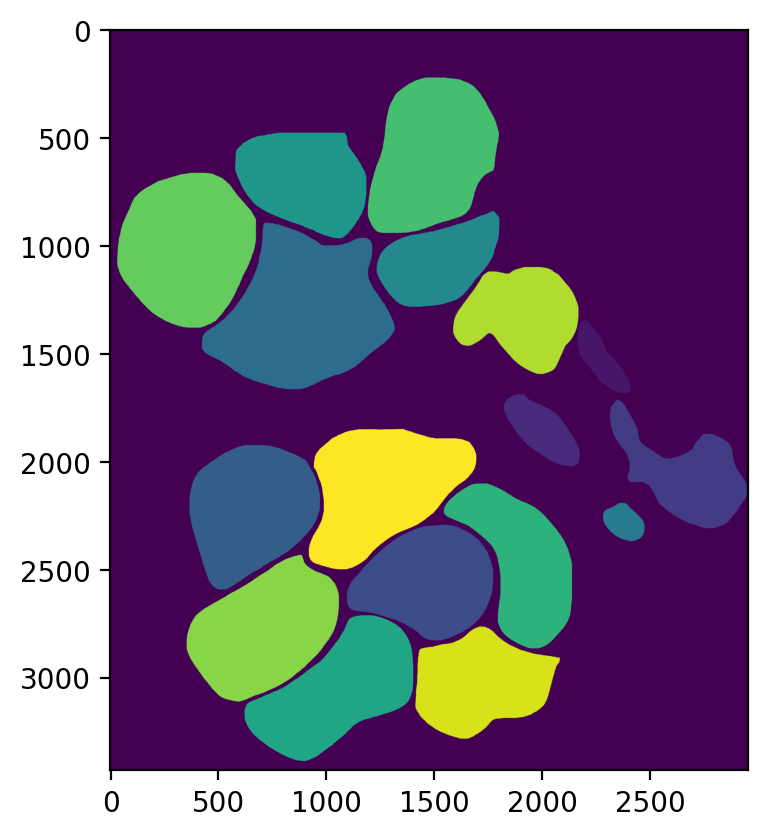

In [ ]:
plt.imshow(cv2.resize(manual_mask, None, fx = 0.1,  fy = 0.1))

#### Segment each region

In [ ]:
result_cyto = []
result_nucleus = []
max_cyto = 0
max_nucleus = 0
os.makedirs("../masks_temp", exist_ok=True)
for i in unique_masks:
    print(i)
    current_mask = (manual_mask == i).astype(np.uint8)
    mask_cyto_global, mask_nucleus_global = get_segmentation_masks_per_region(img_nucleus_original, img_cytoplasm_original, current_mask, "../masks_temp/" + SLIDE_ID + "_" + str(i))
    torch.cuda.empty_cache()
    print(str(torch.cuda.memory_allocated() / (1024**3)))
    print(str(torch.cuda.memory_reserved() / (1024**3)))
    mask_cyto_global = np.multiply((mask_cyto_global > 0).astype(np.uint8), mask_cyto_global.astype(np.uint32) + max_cyto)
    mask_nucleus_global = np.multiply((mask_nucleus_global > 0).astype(np.uint8), mask_nucleus_global.astype(np.uint32) + max_nucleus)
    max_cyto = np.max(np.ravel(mask_cyto_global))
    max_nucleus = np.max(np.ravel(mask_nucleus_global))
    result_cyto.append(mask_cyto_global)
    result_nucleus.append(mask_nucleus_global)

masks_cyto = np.max(np.array(result_cyto), axis = 0)
masks_nucleus = np.max(np.array(result_nucleus), axis = 0)

shape_full = sdata.images["celldive"]["scale0"].image.shape[1:]
masks_full = skimage.transform.resize(masks_cyto, shape_full, order=0, preserve_range=True)
masks_full_nucleus = skimage.transform.resize(masks_nucleus, shape_full, order=0, preserve_range=True)

mask_path = os.path.join("../cellpose_masks_cyto", SLIDE_ID + "masks.npz")
np.savez_compressed(mask_path, masks_full)

mask_path = os.path.join("../cellpose_masks_nucleus", SLIDE_ID + "masks.npz")
np.savez_compressed(mask_path, masks_full_nucleus)

1
Getting bounding box
(3359, 2456)
Extracting region
Segmenting cytoplasm
Segmenting nuclei
0.0089111328125
0.013671875
2
Getting bounding box
(3336, 3509)
Extracting region
Segmenting cytoplasm
Segmenting nuclei
0.0089111328125
0.013671875
3
Getting bounding box
(5921, 6354)
Extracting region
Segmenting cytoplasm
Segmenting nuclei
0.0089111328125
0.013671875
4
Getting bounding box
(5349, 6764)
Extracting region
Segmenting cytoplasm


more than 65535 masks in image, masks returned as np.uint32


Segmenting nuclei


more than 65535 masks in image, masks returned as np.uint32


0.0089111328125
0.013671875
5
Getting bounding box
(6681, 6041)
Extracting region
Segmenting cytoplasm


...

0.0089111328125
0.013671875
17
Getting bounding box
(6493, 7749)
Extracting region
Segmenting cytoplasm


more than 65535 masks in image, masks returned as np.uint32


Segmenting nuclei


more than 65535 masks in image, masks returned as np.uint32


0.0089111328125
0.013671875


### Verify output

In [ ]:
mask_cyto_thumb = cv2.resize(masks_full.astype(np.float32), None, fx = 0.05, fy = 0.05, interpolation=cv2.INTER_LINEAR)
mask_nucleus_thumb = cv2.resize(masks_full_nucleus.astype(np.float32), None, fx = 0.05, fy = 0.05, interpolation=cv2.INTER_LINEAR)

mask_cyto_reference = cv2.resize(masks_full.astype(np.float32), None, fx = 0.5, fy = 0.5, interpolation=cv2.INTER_LINEAR)
mask_nucleus_reference = cv2.resize(masks_full_nucleus.astype(np.float32), None, fx = 0.5, fy = 0.5, interpolation=cv2.INTER_LINEAR)

In [ ]:
img_nucleus_norm = imnormalize(img_nucleus_original)
img_cytoplasm_norm = imnormalize(img_cytoplasm_original)


In [ ]:
bounds = [[11500,12500], [5000,6000]]
bounds = [[7500,10000], [0,2500]]
zoom_nucleus = img_nucleus_norm[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
zoom_cyto = img_cytoplasm_norm[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
zoom_mask = mask_cyto_reference[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
plt.imshow(imoverlay(imblend(zoom_nucleus, zoom_cyto, zoom_cyto), zoom_mask, [1,1,1], px=2))

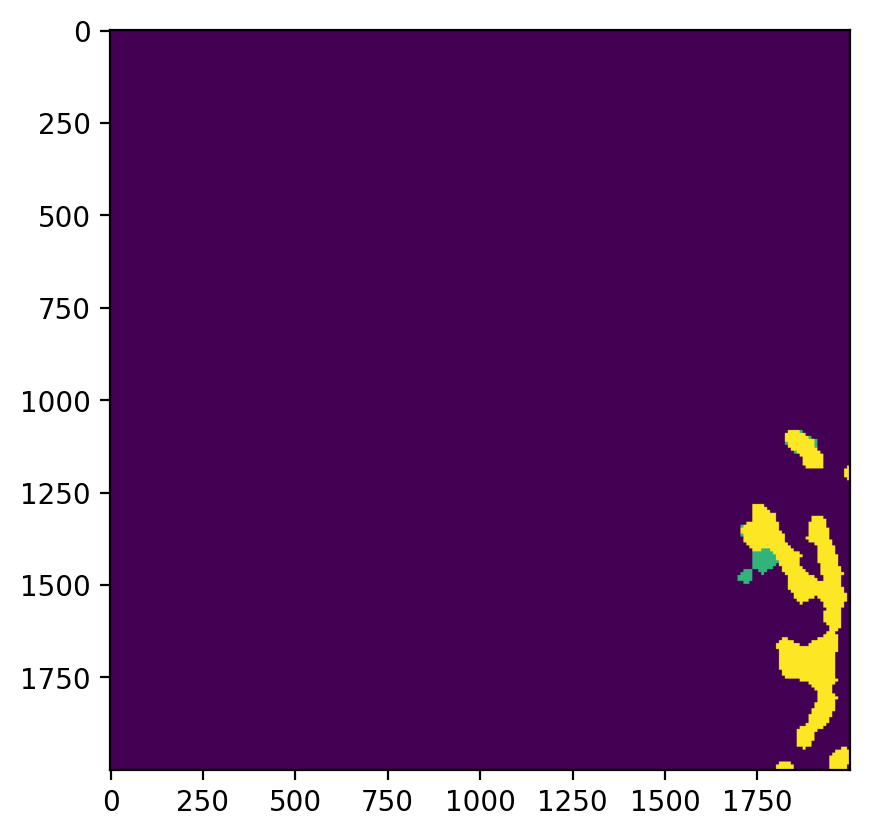

In [ ]:
bounds = [[10000,12000], [10000,12000]]
zoom_mask = masks_full[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
plt.imshow(zoom_mask)

### Consolidate nucleus and cytoplasmic masks

In [ ]:
unique_values_full = np.unique(np.ravel(masks_full))
print("Total cells in cytoplasmic mask: " + str(len(unique_values_full)))

Total cells in cytoplasmic mask: 1201527


In [ ]:
mask_cyto_mask = np.multiply(masks_full, (masks_full_nucleus > 0).astype(np.uint8))
unique_values = np.unique(np.ravel(mask_cyto_mask))
print("Total cells in after intersecting with nuclear mask: " + str(len(unique_values)))

Total cells in after intersecting with nuclear mask: 1192306


In [ ]:
mask_cyto_final = np.multiply(masks_full, np.isin(masks_full, unique_values).astype(np.uint8))
unique_values_final = np.unique(np.ravel(mask_cyto_final))
print("Kept: " + str(len(unique_values_final) / len(unique_values_full)))

Kept: 0.9923255990085948


In [ ]:
os.makedirs("../cellpose_masks_consolidated", exist_ok = True)
mask_path = os.path.join("../cellpose_masks_consolidated", SLIDE_ID + "_masks_nucleus_consolidated.npz")
np.savez_compressed(mask_path, mask_cyto_mask)
mask_path = os.path.join("../cellpose_masks_consolidated", SLIDE_ID + "_masks_cyto_consolidated.npz")
np.savez_compressed(mask_path, mask_cyto_final)

#### Verify that there are no overlaps between segmented cells in different masked regions

In [ ]:
mask_path = os.path.join("cellpose_masks_cyto", SLIDE_ID + "masks.npz")
masks_full = np.load(mask_path)["arr_0"]

mask_path = os.path.join("cellpose_masks_nucleus", SLIDE_ID + "masks.npz")
masks_full_nucleus = np.load(mask_path)["arr_0"]

manual_mask_file = grep(SLIDE_ID, os.listdir("manual_masks"))[0]
manual_mask = skimage.io.imread(os.path.join("manual_masks", manual_mask_file))

result = []
for i in range(len(unique_masks)):
    current_mask = (manual_mask == unique_masks[i]).astype(np.uint8)
    masks_full_temp = np.multiply(masks_full, current_mask)
    unique_values = np.unique(np.ravel(masks_full_temp))
    unique_values = unique_values[unique_values > 0]
    result.append(unique_values)

all_repeated = []
import itertools
for i,j in itertools.product(range(len(unique_masks)), range(len(unique_masks))):
    if(i ==j):
        continue
    all_repeated += list(np.intersect1d(result[i], result[j]))

mask_intersection = np.isin(masks_cyto, all_repeated)
mask_intersection_thumb = cv2.resize(mask_intersection.astype(np.float32), None, fx = 0.05, fy = 0.05)
plt.imshow(cv2.dilate(mask_intersection_thumb, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))))